# Rabi oscillations of a two-level system

### Subject: Quantum electronics

A two-level atom (or a qubit) driven by a resonant field oscillates between
ground and excited state. These **Rabi oscillations** are the heart of
light–matter interaction and of coherent control of qubits.

We integrate the Schrödinger equation for

$$ H = \frac{\Delta}{2}\,Z + \frac{\Omega}{2}\,X $$

and plot the excited-state population over time, on and off resonance.


## 0. Setup


In [1]:
import sys
from pathlib import Path

# Make quantum/_common importable whether the kernel cwd is the repo root
# or the subject folder.
_here = Path.cwd().resolve()
for candidate in (_here, _here.parent, _here.parent.parent):
    if (candidate / "_common").is_dir():
        sys.path.insert(0, str(candidate))
        break

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (8, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

from _common import ket0, PAULI_X, PAULI_Z


def simulate_rabi(
    omega_rabi: float = 2 * np.pi * 1.0,
    detuning: float = 0.0,
    t_max: float = 2.0,
    n_steps: int = 2000,
):
    """Integrate i hbar d|psi>/dt = H|psi| with H = (Delta/2) Z + (Omega/2) X."""
    H = 0.5 * detuning * PAULI_Z + 0.5 * omega_rabi * PAULI_X
    times = np.linspace(0.0, t_max, n_steps)
    dt = times[1] - times[0]

    eigvals, eigvecs = np.linalg.eigh(H)
    U = eigvecs @ np.diag(np.exp(-1j * eigvals * dt)) @ eigvecs.conj().T

    psi = ket0.astype(complex).copy()
    pop_excited = np.empty(n_steps)
    for k in range(n_steps):
        pop_excited[k] = abs(psi[1, 0]) ** 2
        psi = U @ psi
    return times, pop_excited

print("Simulator ready.")


Simulator ready.


## 1. Resonant vs off-resonant drive

On resonance ($\Delta=0$) the excited-state population reaches 1 (full inversion).
With detuning, the effective Rabi frequency grows but the maximum population
drops below 1.


resonant (detuning = 0): max excited-state population = 1.000
off-resonance: max excited-state population = 0.500


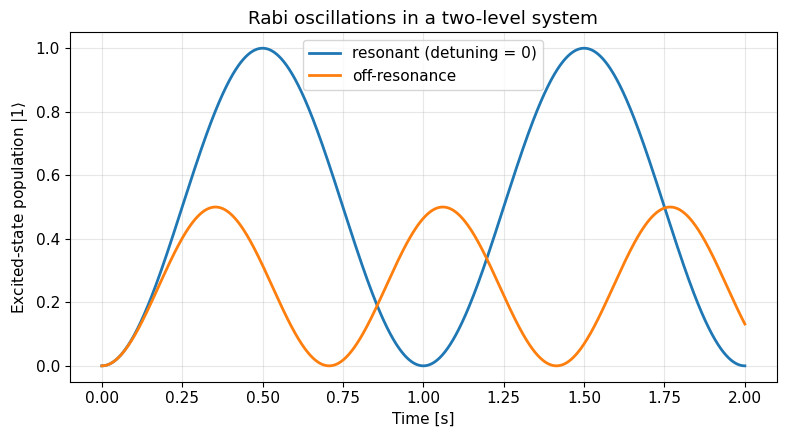

In [2]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for detuning, label in [
    (0.0, "resonant (detuning = 0)"),
    (2 * np.pi * 1.0, "off-resonance"),
]:
    t, pop = simulate_rabi(detuning=detuning)
    ax.plot(t, pop, lw=2, label=label)
    print(f"{label}: max excited-state population = {pop.max():.3f}")

ax.set_xlabel("Time [s]")
ax.set_ylabel(r"Excited-state population $|1\rangle$")
ax.set_title("Rabi oscillations in a two-level system")
ax.set_ylim(-0.05, 1.05)
ax.legend()
plt.tight_layout()
plt.show()


### Next steps
- Add decay (Lindblad master equation, $T_1$ / $T_2$).
- $\pi$ and $\pi/2$ pulses as gates ($X$ and $\sqrt{X}$).
- Absorption spectrum and line broadening.
- For bands, DOS and quantum wells see
  `02_semiconductor_states_and_dos.ipynb`.
